In [1]:
#emag_scraper.py
# Prend en entrée une URL de recherche eMAG (ex: téléphones) et sauvegarde un CSV.
# ATTENTION: vérifie robots.txt et ajoute delays. Usage éducatif.

import requests, time, random, csv
from bs4 import BeautifulSoup
import pandas as pd

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9"
}

# Exemples d'URLs de recherche (adapte la requête selon la catégorie)
# Exemple générique (remplace par la vraie url de recherche eMAG):
# SEARCH_URL_TEMPLATE = "https://www.emag.ro/search/telefoane?ref=listing&page={page}"
SEARCH_URL_TEMPLATE = "https://www.emag.ro/search/telefoane?page={page}"

def parse_product_card(card):
    try:
        title_el = card.select_one("a.card-v2-title") or card.select_one("a.product-title") or card.select_one("h2.product-title a")
        title = title_el.get_text(strip=True) if title_el else ""
        link = title_el["href"] if title_el and title_el.has_attr("href") else ""
        if link and link.startswith("/"):
            link = "https://www.emag.ro" + link
        price_el = card.select_one("p.product-new-price") or card.select_one(".product-new-price")
        price = price_el.get_text(strip=True) if price_el else ""
        price = price.replace("lei","").replace("RON","").replace(".","").strip()
        rating_el = card.select_one(".rating-stars") or card.select_one(".product-rating")
        rating = rating_el.get("data-rating") if rating_el and rating_el.has_attr("data-rating") else ""
        img_el = card.select_one("img")
        img = img_el.get("data-src") or img_el.get("src") if img_el else ""
        return {"title": title, "price_raw": price, "rating": rating, "url": link, "image": img}
    except Exception as e:
        return {}

def scrape_emag(pages=30, out_csv="emag_products.csv"):
    results = []
    for page in range(1, pages+1):
        url = SEARCH_URL_TEMPLATE.format(page=page)
        print("Scraping", url)
        try:
            r = requests.get(url, headers=HEADERS, timeout=15)
        except Exception as e:
            print("Request failed:", e)
            time.sleep(2)
            continue
        if r.status_code != 200:
            print("Status", r.status_code, "— skipping page", page)
            time.sleep(random.uniform(1,2))
            continue
        soup = BeautifulSoup(r.text, "html.parser")
        # selectors peuvent varier selon la version du site: on essaye plusieurs options
        cards = soup.select("div.card-item") + soup.select("div.card") + soup.select("div.product-card")
        if not cards:
            cards = soup.select("div.classic-product-card")  # fallback
        for c in cards:
            row = parse_product_card(c)
            if row and row.get("title"):
                results.append(row)
        print("Got", len(results), "items so far")
        # anti-bann: sleep aléatoire
        time.sleep(random.uniform(0.8, 2.0))
        if len(results) >= 1000:
            break
    df = pd.DataFrame(results)
    df.to_csv(out_csv, index=False)
    print("Saved", len(df), "rows to", out_csv)

if __name__ == "__main__":
    scrape_emag(pages=60, out_csv="emag_phones.csv")


Scraping https://www.emag.ro/search/telefoane?page=1
Got 60 items so far
Scraping https://www.emag.ro/search/telefoane?page=2
Got 120 items so far
Scraping https://www.emag.ro/search/telefoane?page=3
Got 180 items so far
Scraping https://www.emag.ro/search/telefoane?page=4
Got 240 items so far
Scraping https://www.emag.ro/search/telefoane?page=5
Got 300 items so far
Scraping https://www.emag.ro/search/telefoane?page=6
Got 360 items so far
Scraping https://www.emag.ro/search/telefoane?page=7
Got 420 items so far
Scraping https://www.emag.ro/search/telefoane?page=8
Got 480 items so far
Scraping https://www.emag.ro/search/telefoane?page=9
Got 540 items so far
Scraping https://www.emag.ro/search/telefoane?page=10
Got 600 items so far
Scraping https://www.emag.ro/search/telefoane?page=11
Got 660 items so far
Scraping https://www.emag.ro/search/telefoane?page=12
Got 720 items so far
Scraping https://www.emag.ro/search/telefoane?page=13
Got 780 items so far
Scraping https://www.emag.ro/search

In [3]:
import pandas as pd

df = pd.read_csv("emag_phones.csv")
df.head()


,title,price_raw,rating,url,image
0,"Telefon mobil Samsung Galaxy A16, Dual SIM, 12...","580,72Lei",NaN,https://www.emag.ro/telefon-mobil-samsung-gala...,https://s13emagst.akamaized.net/products/77658...
1,"Telefon mobil Samsung Galaxy A16, Dual SIM, 12...","582,29Lei",NaN,https://www.emag.ro/telefon-mobil-samsung-gala...,https://s13emagst.akamaized.net/products/77658...
2,"Telefon mobil Xiaomi Redmi A5, 3GB RAM, 64GB, ...","329,99Lei",NaN,https://www.emag.ro/telefon-mobil-xiaomi-redmi...,https://s13emagst.akamaized.net/products/94270...
3,"Telefon mobil Motorola Edge 60 Fusion, Dual SI...","1199,99Lei",NaN,https://www.emag.ro/telefon-mobil-motorola-edg...,https://s13emagst.akamaized.net/products/93625...
4,"Telefon mobil Motorola Moto g86, 8GB RAM, 256G...","799,99Lei",NaN,https://www.emag.ro/telefon-mobil-motorola-mot...,https://s13emagst.akamaized.net/products/96586...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1020 non-null   object 
 1   price_raw  1020 non-null   object 
 2   rating     0 non-null      float64
 3   url        1020 non-null   object 
 4   image      1020 non-null   object 
dtypes: float64(1), object(4)
memory usage: 40.0+ KB


In [5]:
import pandas as pd
import numpy as np
import re

# Exemple pour ton dataset
df = pd.read_csv("emag_phones.csv")

def clean_price(text):
    if isinstance(text, str):
        # Remplacer la virgule par un point pour float et enlever "Lei"
        text = text.replace(",", ".").replace("Lei","").strip()
        # Extraire le nombre
        nums = re.findall(r"[\d.]+", text)
        if nums:
            return float(nums[0])
    return np.nan

# Appliquer
df["price"] = df["price_raw"].apply(clean_price)

# Vérifier
print(df[["title", "price_raw", "price"]].head(10))
print("Valeurs manquantes price:", df["price"].isna().sum())

                                               title   price_raw    price
0  Telefon mobil Samsung Galaxy A16, Dual SIM, 12...   580,72Lei   580.72
1  Telefon mobil Samsung Galaxy A16, Dual SIM, 12...   582,29Lei   582.29
2  Telefon mobil Xiaomi Redmi A5, 3GB RAM, 64GB, ...   329,99Lei   329.99
3  Telefon mobil Motorola Edge 60 Fusion, Dual SI...  1199,99Lei  1199.99
4  Telefon mobil Motorola Moto g86, 8GB RAM, 256G...   799,99Lei   799.99
5    Telefon mobil Apple iPhone 16, 128GB, 5G, Black  3699,99Lei  3699.99
6  Telefon mobil pentru seniori, cu meniul in lim...   207,01Lei   207.01
7  Telefon mobil Xiaomi Redmi 15, 8GB RAM, 256GB,...   649,99Lei   649.99
8  Telefon mobil Samsung Galaxy A56, Dual SIM, 8G...  1679,27Lei  1679.27
9  Telefon mobil Samsung Galaxy A56, Dual SIM, 8G...  1657,13Lei  1657.13
Valeurs manquantes price: 0


In [6]:
# Storage (ex: 64GB, 128GB)
df["storage"] = df["title"].str.extract(r'(\d+)\s?GB')[0].astype(float)

# RAM (ex: 3GB RAM, 8GB RAM)
df["ram"] = df["title"].str.extract(r'(\d+)\s?GB RAM')[0].astype(float)

# Remplir les valeurs manquantes par la médiane (optionnel)
df["storage"] = df["storage"].fillna(df["storage"].median())
df["ram"] = df["ram"].fillna(df["ram"].median())

In [7]:
df["brand"] = df["title"].str.split().str[2]  # "Samsung", "Xiaomi"…

In [9]:
# Garder uniquement les colonnes utiles
df_ml = df[["price", "storage", "ram", "brand"]].dropna()

# One-Hot Encoding pour brand
df_ml = pd.get_dummies(df_ml, columns=["brand"], drop_first=True)

df_ml.head()

,price,storage,ram,brand_Galaxy,brand_Motorola,brand_Nokia,brand_Samsung,brand_Xiaomi,brand_bluetooth,brand_iHunt,brand_pentru
0,580.72,128.0,4.0,False,False,False,True,False,False,False,False
1,582.29,128.0,4.0,False,False,False,True,False,False,False,False
2,329.99,3.0,3.0,False,False,False,False,True,False,False,False
3,1199.99,12.0,12.0,False,True,False,False,False,False,False,False
4,799.99,8.0,8.0,False,True,False,False,False,False,False,False


In [10]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            1020 non-null   float64
 1   storage          1020 non-null   float64
 2   ram              1020 non-null   float64
 3   brand_Galaxy     1020 non-null   bool   
 4   brand_Motorola   1020 non-null   bool   
 5   brand_Nokia      1020 non-null   bool   
 6   brand_Samsung    1020 non-null   bool   
 7   brand_Xiaomi     1020 non-null   bool   
 8   brand_bluetooth  1020 non-null   bool   
 9   brand_iHunt      1020 non-null   bool   
 10  brand_pentru     1020 non-null   bool   
dtypes: bool(8), float64(3)
memory usage: 32.0 KB


In [11]:
import os
print(os.getcwd())
df_ml.to_csv("emag_phones_ml_ready.csv", index=False, encoding="utf-8-sig")
print("✅ Fichier enregistré dans le dossier courant.")

C:\Users\ryzen 5th
✅ Fichier enregistré dans le dossier courant.


In [12]:
df_ml.to_csv(r"C:\Users\ryzen 5th\Documents\emag_phones_ml_ready.csv", index=False, encoding="utf-8-sig")

In [13]:
#1. Analiză exploratorie (EDA)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Vizualizația date de inceput
display(df_ml.head())
print(df_ml.describe())

,price,storage,ram,brand_Galaxy,brand_Motorola,brand_Nokia,brand_Samsung,brand_Xiaomi,brand_bluetooth,brand_iHunt,brand_pentru
0,580.72,128.0,4.0,False,False,False,True,False,False,False,False
1,582.29,128.0,4.0,False,False,False,True,False,False,False,False
2,329.99,3.0,3.0,False,False,False,False,True,False,False,False
3,1199.99,12.0,12.0,False,True,False,False,False,False,False,False
4,799.99,8.0,8.0,False,True,False,False,False,False,False,False


             price      storage          ram
count  1020.000000  1020.000000  1020.000000
mean   2692.904000    91.816667     8.016667
std    2394.825029   122.698585     2.210848
min      79.990000     2.000000     2.000000
25%     606.132500     8.000000     8.000000
50%    1587.185000    12.000000     8.000000
75%    4776.627500   128.000000     8.000000
max    8699.990000   512.000000    12.000000


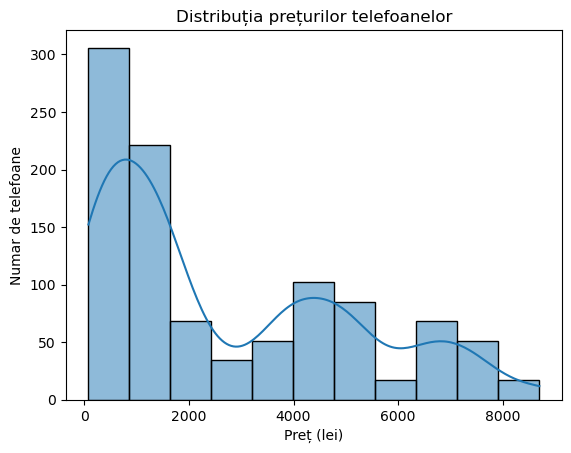

In [14]:
#Distribuția prețurilor
plt.figure()
sns.histplot(df_ml['price'], kde = True)
plt.title("Distribuția prețurilor telefoanelor")
plt.xlabel("Preț (lei)")
plt.ylabel("Numar de telefoane")
plt.show()

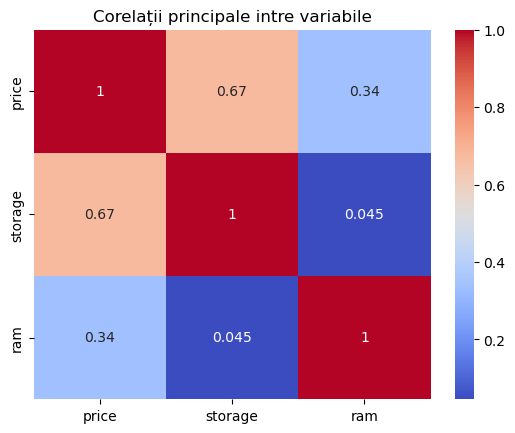

In [15]:
#Corelații intre preț, RAM și Stocare
plt.figure()
sns.heatmap(df_ml[['price', 'storage', 'ram']].corr(), annot=True, cmap="coolwarm")
plt.title("Corelații principale intre variabile")
plt.show()

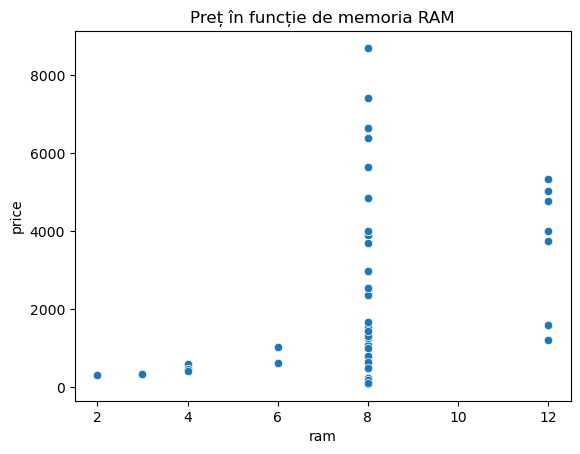

In [16]:
#Relația preț vs RAM
plt.figure()
sns.scatterplot(data= df_ml, x= "ram", y= "price")
plt.title("Preț în funcție de memoria RAM")
plt.show()

brand
Nokia          79.990000
iHunt          99.980000
pentru        209.362500
Xiaomi        531.353333
bluetooth    1000.000000
Motorola     1251.990000
Samsung      2193.623333
Galaxy       5089.038500
Name: price, dtype: float64

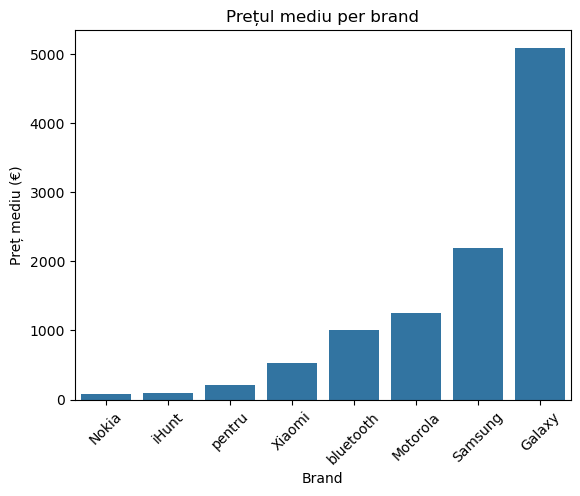

In [17]:
# --- 2. Analiză comparativă între mărci ---
brand_cols = [col for col in df_ml.columns if col.startswith("brand_")]

# Transformăm coloanele booleene într-o singură coloană "brand"
df_ml['brand'] = df_ml[brand_cols].idxmax(axis=1).str.replace('brand_', '')

# Preț mediu pe brand
brand_price_mean = df_ml.groupby('brand')['price'].mean().sort_values()
display(brand_price_mean)

# Vizualizare
plt.figure()
sns.barplot(x=brand_price_mean.index, y=brand_price_mean.values)
plt.title("Prețul mediu per brand")
plt.xlabel("Brand")
plt.ylabel("Preț mediu (€)")
plt.xticks(rotation=45)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Facem o copie pentru a evita modificarea originalului
df_model = df_ml.copy()

# Identificăm coloanele de tip text (object)
categorical_cols = df_model.select_dtypes(include=['object']).columns
print("Coloane text:", list(categorical_cols))

# Transformăm valorile text în variabile numerice (One-Hot Encoding)
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Variabile explicative și ținta
X = df_model.drop(columns=['price'])
y = df_model['price']

# Împărțim în train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Random Forest
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Predicții
y_pred = model.predict(X_test)

# Evaluare
print("Eroare medie absolută (MAE):", mean_absolute_error(y_test, y_pred))
print("Scor R²:", r2_score(y_test, y_pred))

Coloane text: ['brand']
Eroare medie absolută (MAE): 367.25029690539884
Scor R²: 0.930430789875319


C:\Users\ryzen 5th\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\ryzen 5th\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\ryzen 5th\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ryzen 5th\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\ryzen 5th\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid

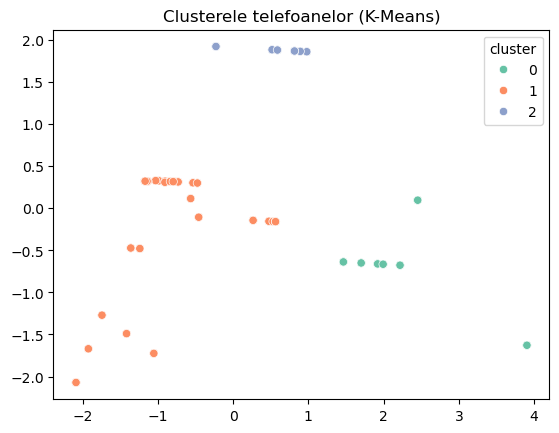

In [19]:
# --- 4. Clustering ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Variabile numerice
X_cluster = df_ml[['price', 'storage', 'ram']]

# Normalizare
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-Means cu 3 clustere
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df_ml['cluster'] = clusters

# Vizualizare 2D (cu PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure()
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_ml['cluster'], palette='Set2')
plt.title("Clusterele telefoanelor (K-Means)")
plt.show()

In [20]:
df_ml = df_ml.drop_duplicates()
print("Număr de rânduri după eliminarea duplicatelor:", len(df_ml))

Număr de rânduri după eliminarea duplicatelor: 51


In [21]:
df_ml.groupby('brand')['price'].nunique()

brand
Galaxy       13
Motorola      7
Nokia         1
Samsung      21
Xiaomi        3
bluetooth     1
iHunt         1
pentru        4
Name: price, dtype: int64

In [22]:
# Elimină toate caracterele non-printabile din codul copiat
import re
code = "(2 * df_ml['ram'] + 0.5 * (df_ml['storage'] / 64)) / (df_ml['price'] / 100)"
clean_code = re.sub(r'\s+', ' ', code)
print(clean_code)

(2 * df_ml['ram'] + 0.5 * (df_ml['storage'] / 64)) / (df_ml['price'] / 100)


,brand,price,ram,storage,raport_calitate_pret
30,Motorola,1599.99,12.0,512.0,3.840024
25,Motorola,499.99,8.0,128.0,2.048041
27,Nokia,79.99,8.0,12.0,1.200150
37,iHunt,99.98,8.0,12.0,0.960192
0,Samsung,580.72,4.0,128.0,0.881664
1,Samsung,582.29,4.0,128.0,0.879287
21,Galaxy,460.01,4.0,64.0,0.556510
43,Samsung,465.00,4.0,64.0,0.550538
52,pentru,186.98,8.0,12.0,0.513424
56,Galaxy,8699.99,8.0,512.0,0.470805


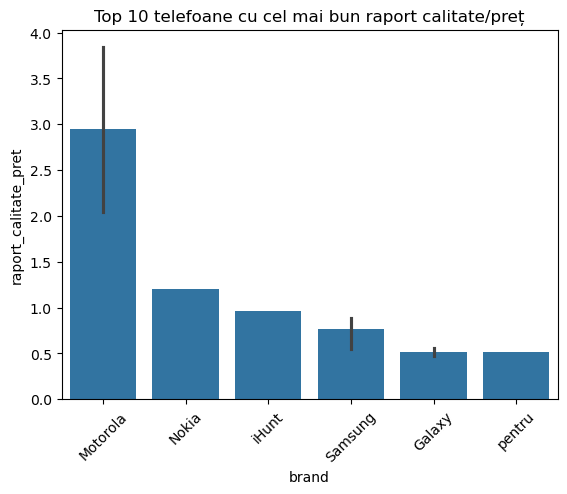

In [29]:
# --- 5. Raport calitate/preț ---
df_ml['raport_calitate_pret'] = (df_ml['ram'] * df_ml['storage']) / df_ml['price']

# Top 10 telefoane cu cel mai bun raport calitate/preț
top_perf = df_ml.sort_values('raport_calitate_pret', ascending=False).head(10)
display(top_perf[['brand', 'price', 'ram', 'storage', 'raport_calitate_pret']])

# Vizualizare
plt.figure()
sns.barplot(x='brand', y='raport_calitate_pret', data=top_perf)
plt.title("Top 10 telefoane cu cel mai bun raport calitate/preț")
plt.xticks(rotation=45)
plt.show()

0    1.549800
1    1.545622
2    1.825339
3    2.007829
4    2.007838
Name: raport_calitate_pret, dtype: float64

C:\Users\ryzen 5th\AppData\Local\Temp\ipykernel_18576\2790620889.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


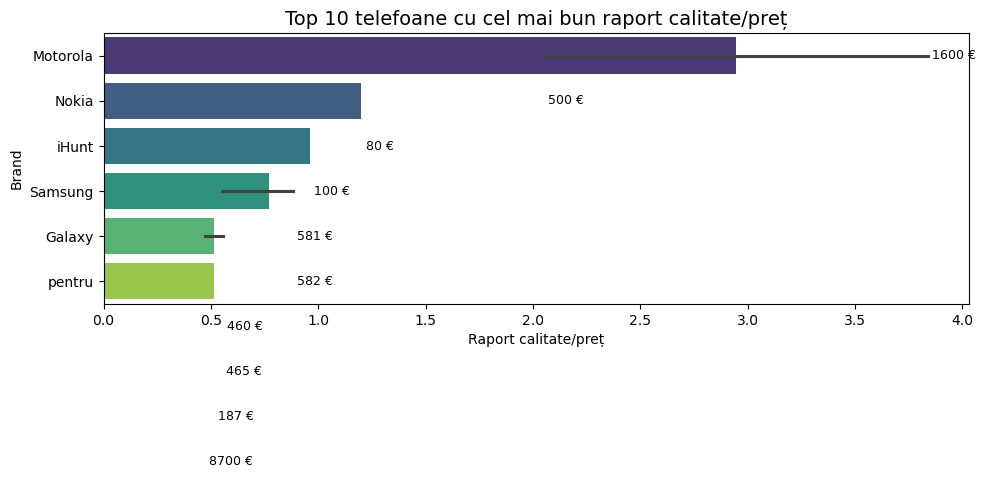

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# On s'assure que le DataFrame est trié
top_perf_sorted = top_perf.sort_values(by='raport_calitate_pret', ascending=False)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x='raport_calitate_pret',
    y='brand',
    data=top_perf_sorted,
    palette='viridis'
)

# Ajout d'étiquettes (prix) à côté de chaque barre
for index, value in enumerate(top_perf_sorted['raport_calitate_pret']):
    price = top_perf_sorted['price'].iloc[index]
    brand = top_perf_sorted['brand'].iloc[index]
    ax.text(
        value + 0.02,                 # position horizontale (légèrement à droite de la barre)
        index,                        # position verticale alignée sur la barre
        f"{price:.0f} €",             # texte affiché
        va='center', 
        ha='left', 
        fontsize=9
    )

plt.title("Top 10 telefoane cu cel mai bun raport calitate/preț", fontsize=14)
plt.xlabel("Raport calitate/preț")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

In [31]:
# Exemplu de produs nou (adaptat la coloanele tale)
nou_produs = pd.DataFrame([{
    'ram': 8,
    'storage': 256,
    'brand_Samsung': 1,   # dacă brandul este Samsung
    'brand_Xiaomi': 0,
    'brand_Motorola': 0,
    # ... alte coloane dacă există
}])

# Completăm coloanele lipsă din model
nou_produs = nou_produs.reindex(columns=X.columns, fill_value=0)

# Prezicem prețul
pret_prezis = model.predict(nou_produs)[0]
print(f"Preț estimat pentru produsul nou: {pret_prezis:.2f} lei")

Preț estimat pentru produsul nou: 6279.62 lei


In [32]:
# --- Predicția prețului pentru fiecare telefon din dataset ---

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Facem o copie a bazei de date
df_model = df_ml.copy()

# 1️⃣ Transformăm coloanele text (ex: brand) în valori numerice
categorical_cols = df_model.select_dtypes(include=['object']).columns
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# 2️⃣ Definim variabilele explicative (X) și ținta (y)
X = df_model.drop(columns=['price'])
y = df_model['price']

# 3️⃣ Împărțim în seturi de antrenare și test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ Antrenăm modelul
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# 5️⃣ Evaluăm performanța
y_pred = model.predict(X_test)
print("Eroare medie absolută (MAE):", mean_absolute_error(y_test, y_pred))
print("Coeficient de determinare (R²):", r2_score(y_test, y_pred))

# 6️⃣ Prezicem prețul pentru FIECARE rând (telefon) din dataset
df_model['pret_prezis'] = model.predict(X)

# 7️⃣ Adăugăm rezultatul în baza originală (df_ml)
df_ml['pret_prezis'] = df_model['pret_prezis']

# --- Rezultat: primele 10 telefoane cu preț real vs preț prezis ---
rezultat = df_ml[['brand', 'ram', 'storage', 'price', 'pret_prezis']].head(10)
print(rezultat)

Eroare medie absolută (MAE): 653.2592090909112
Coeficient de determinare (R²): 0.7361486493175395
      brand   ram  storage    price  pret_prezis
0   Samsung   4.0    128.0   580.72    828.97670
1   Samsung   4.0    128.0   582.29    829.59685
2    Xiaomi   3.0      3.0   329.99    670.28765
3  Motorola  12.0     12.0  1199.99   4127.88935
4  Motorola   8.0      8.0   799.99    815.54415
5    Galaxy   8.0    128.0  3699.99   3683.36780
6    pentru   8.0     12.0   207.01    373.81605
7    Xiaomi   8.0      8.0   649.99    713.52665
8   Samsung   8.0      8.0  1679.27   1671.44980
9   Samsung   8.0      8.0  1657.13   1659.08835


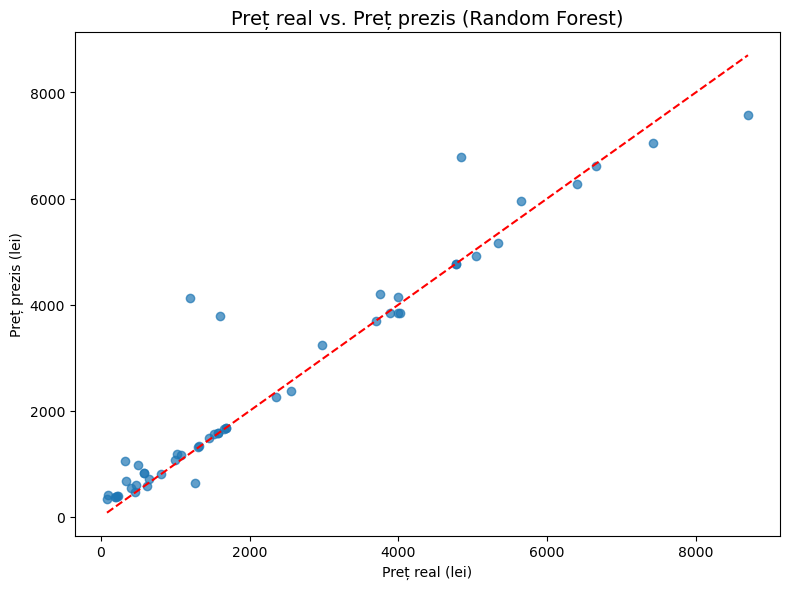

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_ml['price'], df_ml['pret_prezis'], alpha=0.7)
plt.plot(
    [df_ml['price'].min(), df_ml['price'].max()],
    [df_ml['price'].min(), df_ml['price'].max()],
    color='red', linestyle='--'
)
plt.title("Preț real vs. Preț prezis (Random Forest)", fontsize=14)
plt.xlabel("Preț real (lei)")
plt.ylabel("Preț prezis (lei)")
plt.tight_layout()
plt.show()

In [34]:
df_ml['diferenta'] = df_ml['pret_prezis'] - df_ml['price']

# Cele mai subevaluate (preț real < preț prezis)
subevaluate = df_ml.sort_values('diferenta').head(10)

# Cele mai supraevaluate (preț real > preț prezis)
supraevaluate = df_ml.sort_values('diferenta', ascending=False).head(10)

print("🔹 Telefoane subevaluate:")
display(subevaluate[['brand', 'price', 'pret_prezis', 'diferenta']])

print("🔹 Telefoane supraevaluate:")
display(supraevaluate[['brand', 'price', 'pret_prezis', 'diferenta']])

🔹 Telefoane subevaluate:


,brand,price,pret_prezis,diferenta
56,Galaxy,8699.99,7564.06500,-1135.92500
18,Galaxy,1259.99,642.82430,-617.16570
22,Galaxy,7419.99,7048.44000,-371.55000
28,Samsung,5335.97,5156.13160,-179.83840
44,Samsung,2549.99,2370.82790,-179.16210
11,Galaxy,4014.94,3840.32520,-174.61480
42,Galaxy,3999.99,3834.79370,-165.19630
26,Galaxy,6399.99,6267.64960,-132.34040
32,Samsung,5036.89,4914.20265,-122.68735
40,Samsung,2349.00,2266.80520,-82.19480


🔹 Telefoane supraevaluate:


,brand,price,pret_prezis,diferenta
3,Motorola,1199.99,4127.88935,2927.89935
30,Motorola,1599.99,3785.34535,2185.35535
12,Galaxy,4839.99,6789.27650,1949.28650
29,Motorola,315.99,1051.60345,735.61345
25,Motorola,499.99,975.93715,475.94715
34,Samsung,3756.77,4191.94905,435.17905
2,Xiaomi,329.99,670.28765,340.29765
37,iHunt,99.98,418.33885,318.35885
48,Galaxy,5649.99,5945.61980,295.62980
58,Galaxy,2977.97,3239.39770,261.42770
